In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# Cointegration Analysis: Mastercard (MA) and Visa (V)

This notebook examines whether Mastercard (MA) and Visa (V) form a
cointegrated pair (a necessary condition for a pairs-trading strategy).

The workflow:

1. Load 10 years of daily prices (2016–2025).
2. Show that the individual price series are **not** stationary.
3. Show that a linear combination of the two prices **is** stationary.
4. Estimate the half-life of mean reversion for the resulting spread.

**Data:** `data/MA.csv`, `data/V.csv` (cached, see the loading cell for
how to regenerate them with `yfinance`).

## 1. Load Data

We use 10 years of adjusted close prices (2016-01-01 to 2025-12-31).
The CSV cache ensures reproducibility if yfinance's API changes.

In [93]:
# To regenerate the cache, uncomment:
# import os
# ma = yf.download("MA", start="2016-01-01", end="2026-01-01", progress=False, multi_level_index=False)["Close"]
# v  = yf.download("V",  start="2016-01-01", end="2026-01-01", progress=False, multi_level_index=False)["Close"]
# os.makedirs("data", exist_ok=True)
# ma.to_csv("data/MA.csv")
# v.to_csv("data/V.csv")

ma = pd.read_csv("data/MA.csv", index_col=0, parse_dates=True)["Close"]
v  = pd.read_csv("data/V.csv",  index_col=0, parse_dates=True)["Close"]

# Align on common dates (just in case)
ma, v = ma.align(v, join="inner")

print(f"{len(ma)} bars from {ma.index[0].date()} to {ma.index[-1].date()}")

2514 bars from 2016-01-04 to 2025-12-31


## 2. Exploratory Plots

We start with two views of the data:

- **Time series:** both prices move together over time.
- **Scatter plot:** the relationship is linear, with each price
  tracking the other closely. The tightness of the scatter is a
  necessary (but not sufficient) condition for cointegration.

High correlation of **returns** is not the same as cointegration. Two
random walks can be 99% correlated in returns yet drift apart over
years. The tests below check the stronger property.

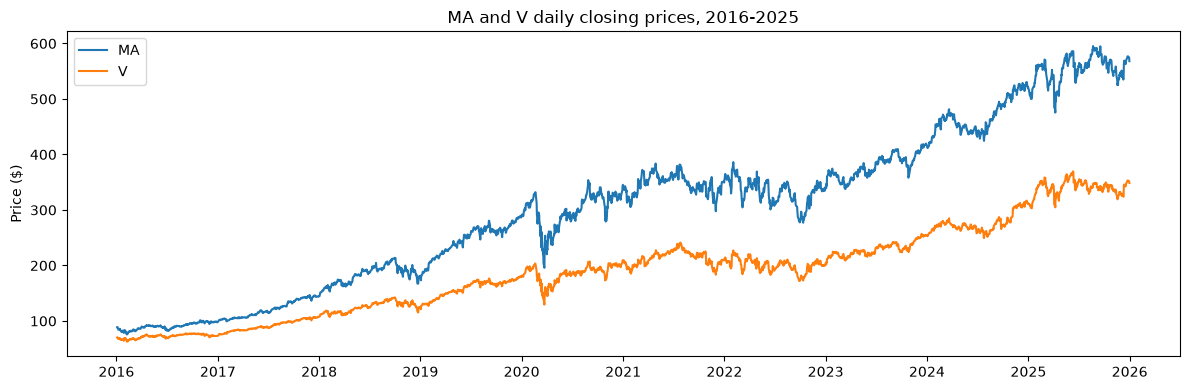

In [82]:
# Price Plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ma.index, ma, label="MA")
ax.plot(v.index, v, label="V")
ax.set_ylabel("Price ($)")
ax.legend()
ax.set_title("MA and V daily closing prices, 2016-2025")
plt.tight_layout()
plt.show()

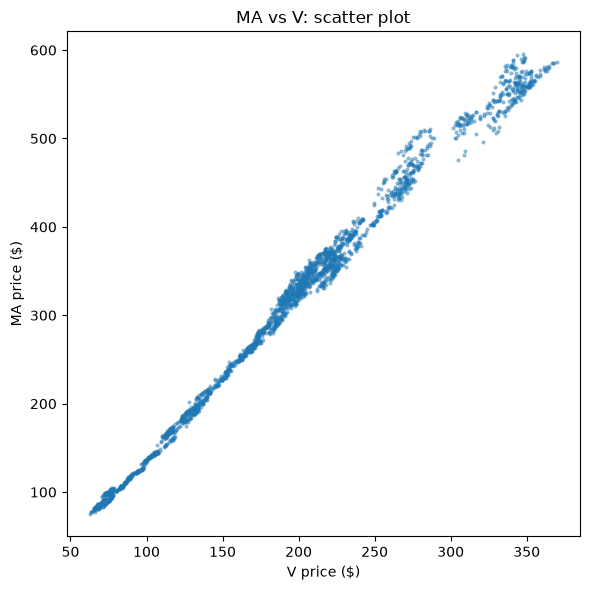

In [84]:
# Scatter Plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(v, ma, s=4, alpha=0.4)
ax.set_xlabel("V price ($)")
ax.set_ylabel("MA price ($)")
ax.set_title("MA vs V: scatter plot")
plt.tight_layout()
plt.show()

## 3. Stationarity of Individual Series

A price series is **stationary** if its statistical properties (mean,
variance) don't change over time. The **Augmented Dickey-Fuller (ADF)**
test checks this:

- **Null hypothesis (H₀):** the series has a unit root (i.e., is a
  random walk — not stationary).
- **Alternative (H₁):** the series is stationary.

We reject H₀ if the ADF statistic is more negative than the critical
value, or equivalently if the p-value is below 0.05.

Because MA and V are trending price series, we expect **both to fail
the ADF test** — the p-values should be large.

In [85]:
for name, series in [("MA", ma), ("V", v)]:
    result = adfuller(series, maxlag=1, regression="c", result_object=False)
    print(f"{name}: ADF = {result[0]:.3f}, p-value = {result[1]:.3f}")

MA: ADF = -0.511, p-value = 0.890
V: ADF = -0.345, p-value = 0.919


## 4. Cointegration

Two non-stationary series are **cointegrated** if some linear combination
of them is stationary. Intuitively: they may wander individually, but
they wander *together*, and the spread between them is bounded.

We test cointegration two ways:

### 4.1 Engle-Granger (CADF) Test

Regress MA on V, then apply the ADF test to the residuals. The test
statistic is compared to Engle-Granger critical values (more negative
than the plain ADF because the hedge ratio was estimated using ordinary least squares).

### 4.2 Johansen Test

A more general test that:

- Handles any number of series.
- Is symmetric (doesn't depend on which series is the "dependent"
  variable).
- Reports the number of independent cointegrating relationships via
  the **trace statistic** and **eigenvalue statistic**.

For a pair, we expect **r = 1** cointegrating relationship.

In [86]:
# CADF Test
t_stat, p_value, crit = coint(ma, v)
print(f"Engle-Granger t-stat: {t_stat:.3f}")
print(f"P-value:              {p_value:.4f}")
print(f"Critical values (1%, 5%, 10%): {crit}")

Engle-Granger t-stat: -4.512
P-value:              0.0012
Critical values (1%, 5%, 10%): [-3.90080341 -3.33856248 -3.04613813]


The t-statistic is more negative than the 1% critical value, so we reject the null hypothesis of **no cointegration** at 99% confidence. MA and V are cointegrated.

In [87]:
# Johansen Test
df = pd.concat([ma, v], axis=1).dropna()
df.columns = ["MA", "V"]

# Note: coint_johansen sometimes returns complex numbers due to
# floating-point roundoff in the eigen-decomposition. We cast to real.
result = coint_johansen(df, det_order=0, k_ar_diff=1)

print("Trace statistic:")
for i, (stat, crit) in enumerate(zip(result.lr1, result.cvt[:, 1])):
    reject = "reject" if stat > crit else "fail to reject"
    print(f"  r <= {i}: trace = {stat:.3f}, 95% crit = {crit:.3f} → {reject}")

print(f"\nEigenvalues: {np.real(result.eig)}")
print(f"\nEigenvectors (first column = strongest):")
print(np.real(result.evec))

Trace statistic:
  r <= 0: trace = 20.720, 95% crit = 15.494 → reject
  r <= 1: trace = 0.153, 95% crit = 3.841 → fail to reject

Eigenvalues: [8.15403679e-03 6.10688956e-05]

Eigenvectors (first column = strongest):
[[ 0.08126414 -0.00281261]
 [-0.14458646  0.01771302]]


/Users/mohsin/Documents/Projects/AlgoTrading/.venv/lib/python3.12/site-packages/statsmodels/tsa/vector_ar/vecm.py:717: ComplexWarning: Casting complex values to real discards the imaginary part
  lr1[i] = -t * np.sum(tmp, 0)
/Users/mohsin/Documents/Projects/AlgoTrading/.venv/lib/python3.12/site-packages/statsmodels/tsa/vector_ar/vecm.py:718: ComplexWarning: Casting complex values to real discards the imaginary part
  lr2[i] = -t * np.log(1 - a[i])


The first eigenvalue (0.0082) is two orders of magnitude larger than the second (0.00006), confirming that the first cointegrating vector is by far the strongest.

The trace statistic rejects r ≤ 0 but fails to reject r ≤ 1. This means there is exactly **one** cointegrating relationship — the expected result for a pair.

The eigenvector in the first column gives the hedge ratio. Combined with the intercept from the Engle-Granger regression, it defines the spread portfolio we will trade.

## 5. The Spread and Half-Life

We now construct the spread using the Engle-Granger hedge ratio:

$$\text{spread}(t) = \text{MA}(t) - \beta \cdot \text{V}(t) - \mu$$

If MA and V are cointegrated, this spread is stationary — it oscillates
around zero.

Hedge ratio (beta): 1.7843
Intercept (mu):     -35.6424


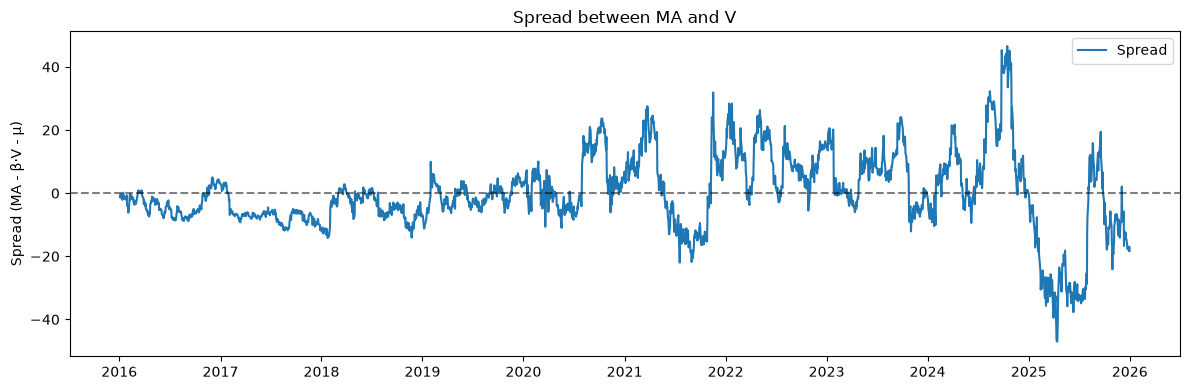

In [88]:
# Spread Plot
X = sm.add_constant(v.values)
model = sm.OLS(ma.values, X).fit()
beta = model.params[1]
mu = model.params[0]
spread = ma - beta * v - mu

print(f"Hedge ratio (beta): {beta:.4f}")
print(f"Intercept (mu):     {mu:.4f}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(spread.index, spread, label="Spread")
ax.axhline(0, color="black", ls="--", alpha=0.5)
ax.set_ylabel("Spread (MA - β·V - μ)")
ax.set_title("Spread between MA and V")
ax.legend()
plt.tight_layout()
plt.show()

### Half-Life of Mean Reversion

We fit an Ornstein-Uhlenbeck regression to the spread:

$$\Delta \varepsilon(t) = \lambda \cdot \varepsilon(t-1) + c + \text{noise}$$

The half-life is then:

$$\text{half-life} = -\frac{\ln 2}{\lambda}$$

This tells us how long a deviation takes to decay halfway back to
the mean. Shorter half-lives mean faster reversion and more tradeable
spreads. As a rule of thumb:

- Half-life < 10 days: very fast, good for daily strategies.
- 10–50 days: reasonable, suitable for a Bollinger strategy with a
  lookback of ~2× the half-life.
- 50–200 days: slow, requires patience and higher transaction-cost
  tolerance.
- more than 200 days: generally not tradeable.

In [94]:
dy = np.diff(spread.values)
lag = spread.values[:-1]
X = sm.add_constant(lag)
model = sm.OLS(dy, X).fit()
lam = model.params[1]
halflife = -np.log(2) / lam

print(f"Lambda:    {lam:.4f}")
print(f"Half-life: {halflife:.1f} days")

Lambda:    -0.0193
Half-life: 35.8 days


The spread between MA and V is stationary with a half-life of 36 days. This means that if the spread deviates from its mean, we can expect it to close half the gap in about 36 trading days. For a daily strategy, this suggests a lookback window of 30–70 days (roughly 1–2 half-lives) and a holding period of a few weeks per round trip. Whether this is tradeable depends on transaction costs and the size of typical deviations — which we'll examine in the strategy notebook.

## Summary

- MA and V are both **non-stationary** (ADF fails to reject the unit
  root on each series individually).
- They are **cointegrated** at 99% confidence (Engle-Granger) and the
  Johansen test finds exactly **one** cointegrating relationship.
- The spread has a **half-life of about 36 days**, which is slow enough
  that round-trip trades take weeks, but not so slow that the strategy
  is impractical.

Next step: apply these results in a Kalman-filtered Bollinger strategy. The Kalman filter estimates a dynamic hedge ratio, and Bollinger bands on the resulting spread generate entry/exit signals.